### **Description**

This recipe shows how to extract scalar and vector variables along the boundary of a regional subdomain using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
When analysing ocean models, it is often useful to diagnose fluxes across and properties along the boundary of a geographically defined region (e.g., a semi-enclosed sea, shelf, etc.).

In NEMO, scalar quantities, such as temperature, salinity, and sea ice concentration are defined at grid cell centres (**T**-points), while velocity components are staggered on cell faces (**U**- and **V**-grid points). This staggering means that extracting a boundary around a masked region requires us to form the set of grid cell faces where normal velocities are defined before interpolating scalar quantities onto these oriented boundary segments.

In this recipe, we show how to use the `extract_mask_boundary()` method of the `NEMODataTree` to extract properties and normal velocities across a closed boundary of a masked region within a NEMO ocean model domain.

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import nemo_cookbook as ncb
from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing IHO World Seas polygons**
**Let's begin by loading the polygons defining the IHO World Seas regions**. 


In [2]:
# Open IHO World Seas polygons from GitHub as Pandas DataFrame:
filepaths = ncb.examples.get_filepaths("IHO")

df_IHO_World_Seas = pd.read_parquet(filepaths['IHO_World_Seas_v3_polygons.parquet'])
df_IHO_World_Seas

,ID,Name,MRGID,Longitudes,Latitudes
0,0,Rio de La Plata,4325,"[[-54.943023652717045, -54.978746687192626, -5...","[[-34.947906883078645, -34.97439280639835, -35..."
1,1,Bass Strait,4366,"[[149.90464234356938, 149.9049998519617, 149.9...","[[-37.54324781853184, -37.54805552943908, -37...."
2,2,Great Australian Bight,4276,"[[143.53250818354263, 143.54855731580784, 143....","[[-38.855345058560204, -38.89580867390668, -38..."
3,3,Tasman Sea,4365,"[[159.03333000000018, 159.03983414634163, 159....","[[-29.999999999999986, -30.043495934959335, -3..."
4,4,Mozambique Channel,4261,"[[43.38217926066437, 43.426910578414024, 43.47...","[[-11.370205640977488, -11.374667237992885, -1..."
...,...,...,...,...,...
96,96,Laccadive Sea,4269,"[[79.19056582495296, 79.20560240772511, 79.205...","[[9.28162992038466, 9.280296445224849, 9.28018..."
97,97,Skagerrak,2379,"[[10.66160702664314, 10.662945270907699, 10.66...","[[59.91287636715083, 59.910394549469004, 59.90..."
98,98,Norwegian Sea,2353,"[[16.72106314339885, 16.78890655530549, 16.856...","[[76.5645473926769, 76.50603497544391, 76.4475..."
99,99,Ligurian Sea,3363,"[[9.834412487214706, 9.835301503777828, 9.8349...","[[44.0485148685363, 44.04729517147973, 44.0472..."


### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [3]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the conservative temperature and absolute salinity stored at T-points in a single dataset.**

In [4]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1y"

# Construct NEMO model T-grid dataset, including sea surface temperature (degC) and sea surface salinity (g/kg):
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={}).sel(time_counter=slice('2000-01', '2020-12'))

ds_gridT

<xarray.Dataset> Size: 17GB
Dimensions:                (time_counter: 21, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * time_counter           (time_counter) datetime64[ns] 168B 2000-07-02 ... ...
    time_centered          (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_qns_li            (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:28:01 GMT
    uuid:         89824b34-5d44-4531-8344-fe1ce39fbb7b

**Next, we need to import the zonal velocity stored at U-points in a single dataset.**

In [5]:
# Define directory path to model output files:
gridU_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1y"

# Construct NEMO model U-grid dataset, including zonal seawater velocity (m/s):
ds_gridU = xr.open_zarr(gridU_url, consolidated=True, chunks={}).sel(time_counter=slice('2000-01', '2020-12'))

ds_gridU

<xarray.Dataset> Size: 4GB
Dimensions:               (depthu: 75, axis_nbounds: 2, time_counter: 21,
                           y: 331, x: 360)
Coordinates:
  * depthu                (depthu) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 168B 2000-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/14)
    depthu_bounds         (depthu, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3u                   (time_counter, depthu, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfx                   (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_adv               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfx_diff              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    sozosatr              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 336B dask.array<chunksize=(1, 2), meta=np.ndarray>
    u2o                   (time_counter, depthu, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo                   (time_counter, depthu, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    umo_vint              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    uo                    (time_counter, depthu, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    uo_eiv                (time_counter, depthu, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_U
    description:  ocean U grid variables
    title:        ocean U grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         8156ec68-1106-4f56-9f8c-d8798e1bd32f

**Next, we need to import the meridional velocity stored at V-points in a single dataset.**

In [6]:
# Define directory path to model output files:
gridV_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1y"

# Construct NEMO model V-grid dataset, including meridional seawater velocity (m/s):
ds_gridV = xr.open_zarr(gridV_url, consolidated=True, chunks={}).sel(time_counter=slice('2000-01', '2020-12'))

ds_gridV

<xarray.Dataset> Size: 4GB
Dimensions:               (depthv: 75, axis_nbounds: 2, time_counter: 21,
                           y: 331, x: 360)
Coordinates:
  * depthv                (depthv) float32 300B 0.5058 1.556 ... 5.902e+03
  * time_counter          (time_counter) datetime64[ns] 168B 2000-07-02 ... 2...
    time_centered         (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/13)
    depthv_bounds         (depthv, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfy                   (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_adv               (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_diff              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    somesatr              (time_counter, y, x) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 336B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 336B dask.array<chunksize=(1, 2), meta=np.ndarray>
    v2o                   (time_counter, depthv, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vmo                   (time_counter, depthv, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo                    (time_counter, depthv, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo_eiv                (time_counter, depthv, y, x) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Creating a NEMODataTree**

**Using our outputs, let's create a NEMODataTree to store our domain and T-grid variables for the eORCA1 model.**

In [7]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
# Note: domain_cfg z-dimension is expected to be named 'nav_lev'.
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT, "gridU": ds_gridU, "gridV": ds_gridV}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=False)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 21, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 168B 2000-07-02 ... 2...
│       time_centered         (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 336B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 336B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 21, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│           time_centered          (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/78)
│           berg_latent_heat_flux  (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 751MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           zos                    (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           zossq                  (time_counter, j, i) float32 10MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) bool 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) bool 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 21, j: 331,
│                                  i: 360)
│       Coordinates:
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * depthu                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered         (time_counter) datetime64[ns] 168B dask.array<chunksize=(1,), meta=np.ndarray>
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) float64 3kB 1.5 2.5 3.5 4.5 ... 358.5 359.5 360.5
│           gphiu                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Dimensions

**Now, we will use the IHO World Seas polygons to extract the Barents Sea from the eORCA1 model domain.**

In [8]:
# Define IHO World Seas Barents Sea polygon:
lon_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Barentsz Sea']['Longitudes'].item()[0]
lat_poly = df_IHO_World_Seas[df_IHO_World_Seas['Name'] == 'Barentsz Sea']['Latitudes'].item()[0]

# Define boolean mask for NEMO model T-point contained within the Barents Sea:
mask = nemo.mask_with_polygon(grid='gridT', lon_poly=lon_poly, lat_poly=lat_poly)

**Next, let's plot the mean sea surface temperature of our eORCA1 model within the IHO World Seas polygons for the Barents Sea:**

/var/folders/z2/j_dr250s42x34hk63_rp4bm80000gq/T/ipykernel_10946/3108725572.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(nemo['gridT/glamt'], nemo['gridT/gphit'], nemo['gridT/tos_con'].where(mask).mean(dim='time_counter'), cmap='RdBu_r')


(60.0, 90.0)

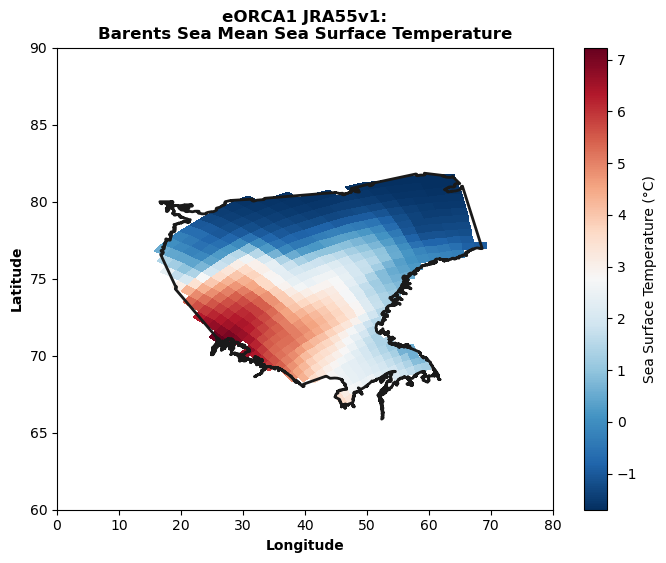

In [9]:
# -- Plot time-mean sea surface temperature (°C) in the Barents Sea, with IHO World Seas polygon overlaid -- #
plt.figure(figsize=(8, 6))

plt.pcolormesh(nemo['gridT/glamt'], nemo['gridT/gphit'], nemo['gridT/tos_con'].where(mask).mean(dim='time_counter'), cmap='RdBu_r')
plt.plot(lon_poly, lat_poly, color='0.1', lw=2)
plt.colorbar(label='Sea Surface Temperature (°C)')

# Axes labels:
plt.title("eORCA1 JRA55v1:\nBarents Sea Mean Sea Surface Temperature", fontdict={"size": 12, "weight": "bold"})
plt.xlabel('Longitude', fontdict={"size": 10, "weight": "bold"})
plt.ylabel('Latitude', fontdict={"size": 10, "weight": "bold"})
plt.xlim([0, 80])
plt.ylim([60, 90])

### **Extracting velocities and properties along the boundary of the Barents Sea**

**Now we have explored our `NEMODataTree`, let's extract the normal velocities and conservative temperature along the boundary of the Barent Sea region in our eORCA1 domain.**

We must define the names of the zonal and meridional velocity components as a list `uv_vars` and the names of any scalar variables defined on **T**-grid points (`vars`) we would like to extract along the boundary.

In [10]:
# Extract mask boundary as an xarray.Dataset, including geographical coordinates and grid scale factors along the boundary:
ds_bdy = nemo.extract_mask_boundary(mask=mask, uv_vars=["uo", "vo"], vars=["thetao_con"], dom=".")

ds_bdy

<xarray.Dataset> Size: 5MB
Dimensions:       (bdy: 140, time_counter: 21, k: 75)
Coordinates:
  * bdy           (bdy) int64 1kB 0 1 2 3 4 5 6 ... 133 134 135 136 137 138 139
    glamb         (bdy) float64 1kB 68.38 66.5 65.69 64.9 ... 67.12 68.21 69.25
    gphib         (bdy) float64 1kB 76.92 76.88 76.63 ... 77.58 77.37 77.16
    depthb        (k, bdy) float64 84kB 0.5058 0.5058 ... 5.902e+03 5.902e+03
  * time_counter  (time_counter) datetime64[ns] 168B 2000-07-02 ... 2020-07-02
  * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
Data variables:
    i_bdy         (bdy) float64 1kB 294.5 294.5 295.0 ... 293.0 293.5 294.0
    j_bdy         (bdy) float64 1kB 329.0 328.0 327.5 ... 328.5 329.0 329.5
    flux_type     (bdy) <U1 560B 'U' 'U' 'V' 'U' 'U' 'U' ... 'V' 'V' 'V' 'U' 'V'
    flux_dir      (bdy) int64 1kB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 -1 1
    velocity      (time_counter, k, bdy) float64 2MB dask.array<chunksize=(21, 75, 140), meta=np.ndarray>
    bmask         (k, bdy) float64 84kB dask.array<chunksize=(75, 140), meta=np.ndarray>
    e1b           (bdy) float64 1kB dask.array<chunksize=(140,), meta=np.ndarray>
    e3b           (time_counter, k, bdy) float64 2MB dask.array<chunksize=(21, 75, 140), meta=np.ndarray>
    thetao_con    (time_counter, k, bdy) float64 2MB dask.array<chunksize=(21, 75, 140), meta=np.ndarray>

**Taking a closer look at our boundary dataset, we can see it is structured analogously to a NEMO model grid node within our `NEMODataTree`:**

* Inherited NEMO Grid Dimension: `k`

* New Along-Boundary Grid Dimension: `bdy`, such that `i_bdy(bdy)`, `j_bdy(bdy)`

* Geographical Coordinates: `glamb` (longitude), `gphib` (latitude).

* Horizontal Grid Scale Factors: `e1b`

* Vertical Grid Scale Factors: `e3b`

* Land-Sea Mask: `bmask`

The `xarray.Dataset` also includes `flux_type` which defines the type of vector point the grid cell faces is and `flux_dir` which specifies the sign of each normal velocity component.

The `velocity` variable therefore represents a combination of zonal (**U**) and meridional (**V**) velocities to which the appropriate `flux_dir` has **already** been applied.

### **Visualising the geographical locations of the Barents Sea boundary indexes**

**Next, let's visualise the locations of the NEMO model U/V-grid points which form the closed boundary around the Barents Sea:**

We can see that the boundary index `bdy` increases clockwise to form a closed loop around the boundary.

(290.0, 331.0)

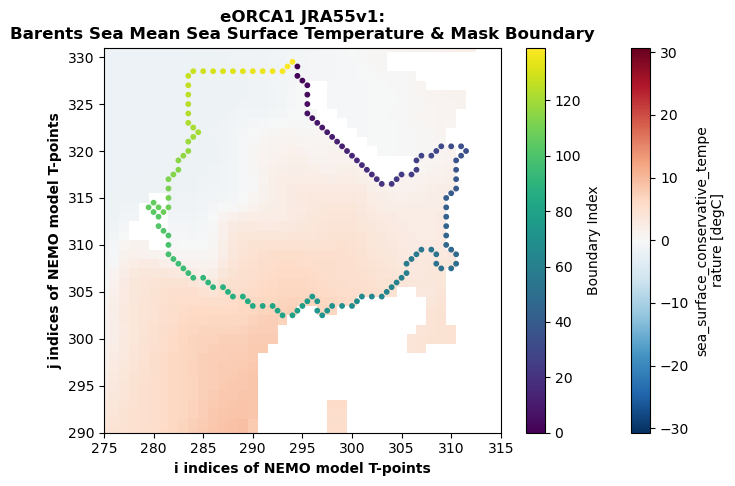

In [11]:
# -- Plot time-mean sea surface temperature (°C) & Barents Sea boundary -- #
plt.figure(figsize=(8, 5))

# Plot time-mean sea surface temperature (°C) in the Barents Sea:
nemo['gridT/tos_con'].masked.mean(dim='time_counter').plot()

# Plot mask boundary points coloured by their boundary index:
scatter = plt.scatter(ds_bdy['i_bdy'], ds_bdy['j_bdy'], c=ds_bdy['bdy'], s=10)
plt.colorbar(scatter, label='Boundary Index')

# Add axes limits:
plt.title("eORCA1 JRA55v1:\nBarents Sea Mean Sea Surface Temperature & Mask Boundary", fontdict={"size": 12, "weight": "bold"})
plt.xlabel('i indices of NEMO model T-points', fontdict={"size": 10, "weight": "bold"})
plt.ylabel('j indices of NEMO model T-points', fontdict={"size": 10, "weight": "bold"})
plt.xlim([275, 315])
plt.ylim([290, 331])

### **Visualising conservative temperature along the Barents Sea boundary**

**Finally, let's visualise a snapshot of the conservative temperature field along the boundary of the Barents Sea:**

Since the boundary is defined on staggered **U** and **V**-grid points, scalar variables are linearly interpolated onto the NEMO model vector grid points which form the closed boundary within the `extract_mask_boundary()` method.

This also means that we can calculate tracer transports across the boundary as the product of the chosen tracer variable (e.g., `thetao_con`), the normal velocity (`velocity`) and the boundary grid scale factors (`e1b` and `e3b`) stored in the boundary `xarray.Dataset`.

(550.0, 0.0)

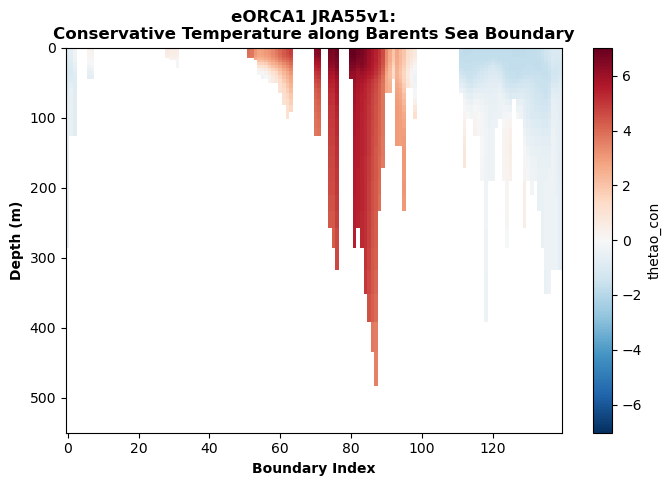

In [12]:
# -- Plot scalar property interpolated along the Barents Sea boundary -- #
plt.figure(figsize=(8, 5))

# Plot conservative temperature (°C) along the Barents Sea boundary:
ds_bdy['thetao_con'].isel(time_counter=0).plot(y='depthb', yincrease=False)

# Axes labels:
plt.title("eORCA1 JRA55v1:\nConservative Temperature along Barents Sea Boundary", fontdict={"size": 12, "weight": "bold"})
plt.xlabel("Boundary Index", fontdict={"size": 10, "weight": "bold"})
plt.ylabel("Depth (m)", fontdict={"size": 10, "weight": "bold"})
plt.ylim([550, 0])